# Resolution Chart ROI Explorer
Identifies and previews the regions of interest on the 20260323 resolution chart
that can be used to quantify super-resolution improvement.

**Chart features available:**
- Slanted edge (diagonal spoke, top-right) → MTF50 via slanted-edge method  
- Horizontal converging wedge (right of centre square) → contrast vs spatial frequency  
- Vertical converging wedge (above centre square) → contrast vs spatial frequency  
- Centre bullseye (for visual inspection)

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from PIL import Image
from scipy.ndimage import gaussian_filter1d

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120})

## 1. Load image

In [83]:
# Pick any combo to explore the chart geometry — all share the same chart layout
SAMPLE_DIR = '/Users/shuyu/ENPH459-Super-Resolution/imaging/sr/20260323_202456/tilt0.14128_settle50.0ms'

img = np.array(Image.open(f'{SAMPLE_DIR}/center.png'), dtype=np.float64)
print(f'Image shape: {img.shape}  (rows × cols)   dtype: {img.dtype}')
print(f'Intensity range: [{img.min():.0f}, {img.max():.0f}]')

Image shape: (1536, 2048)  (rows × cols)   dtype: float64
Intensity range: [14, 255]


## 2. ROI definitions

In [84]:
# ── ROI coordinates (row0, row1, col0, col1) in LR pixel space ──
#
# Slanted edge: the diagonal spoke in the top-right quadrant.
# A clean ~300×370 px section with a straight dark/light transition.
EDGE_ROI     = (300, 480, 1280, 1450)   # (r0, r1, c0, c1)
EDGE_ORIENT  = 'slanted'                # diagonal — angle estimated below

# Horizontal wedge: converging horizontal lines to the RIGHT of the centre square.
# Lines get finer toward the LEFT (chart centre ~col 1020).
# Numbers 1000–1600 TVL/PH are labelled on the chart.
Hwedge_ROI   = (700, 730, 1210, 1500)  # 240 × 450 px

# Vertical wedge: converging vertical lines ABOVE the centre square.
# Lines get finer toward the BOTTOM (chart centre ~row 760).
VWEDGE_ROI   = (200,  540, 1070, 1100)  # 440 × 310 px

# Centre bullseye (visual reference only)
BULLSEYE_ROI = (670, 760, 1000, 1080)   # 270 × 255 px

PIXEL_PITCH_UM = 3.45   # µm / pixel
PITCH_LR_MM    = PIXEL_PITCH_UM * 1e-3
NYQUIST_LR     = 0.5 / PITCH_LR_MM    # 144.9 cy/mm

ROIS = {
    'Slanted edge':       EDGE_ROI,
    'Horiz wedge':        Hwedge_ROI,
    'Vert wedge':         VWEDGE_ROI,
    'Bullseye':           BULLSEYE_ROI,
}
ROI_COLORS = {
    'Slanted edge': 'cyan',
    'Horiz wedge':  'lime',
    'Vert wedge':   'yellow',
    'Bullseye':     'magenta',
}

## 3. Full image with annotated ROIs

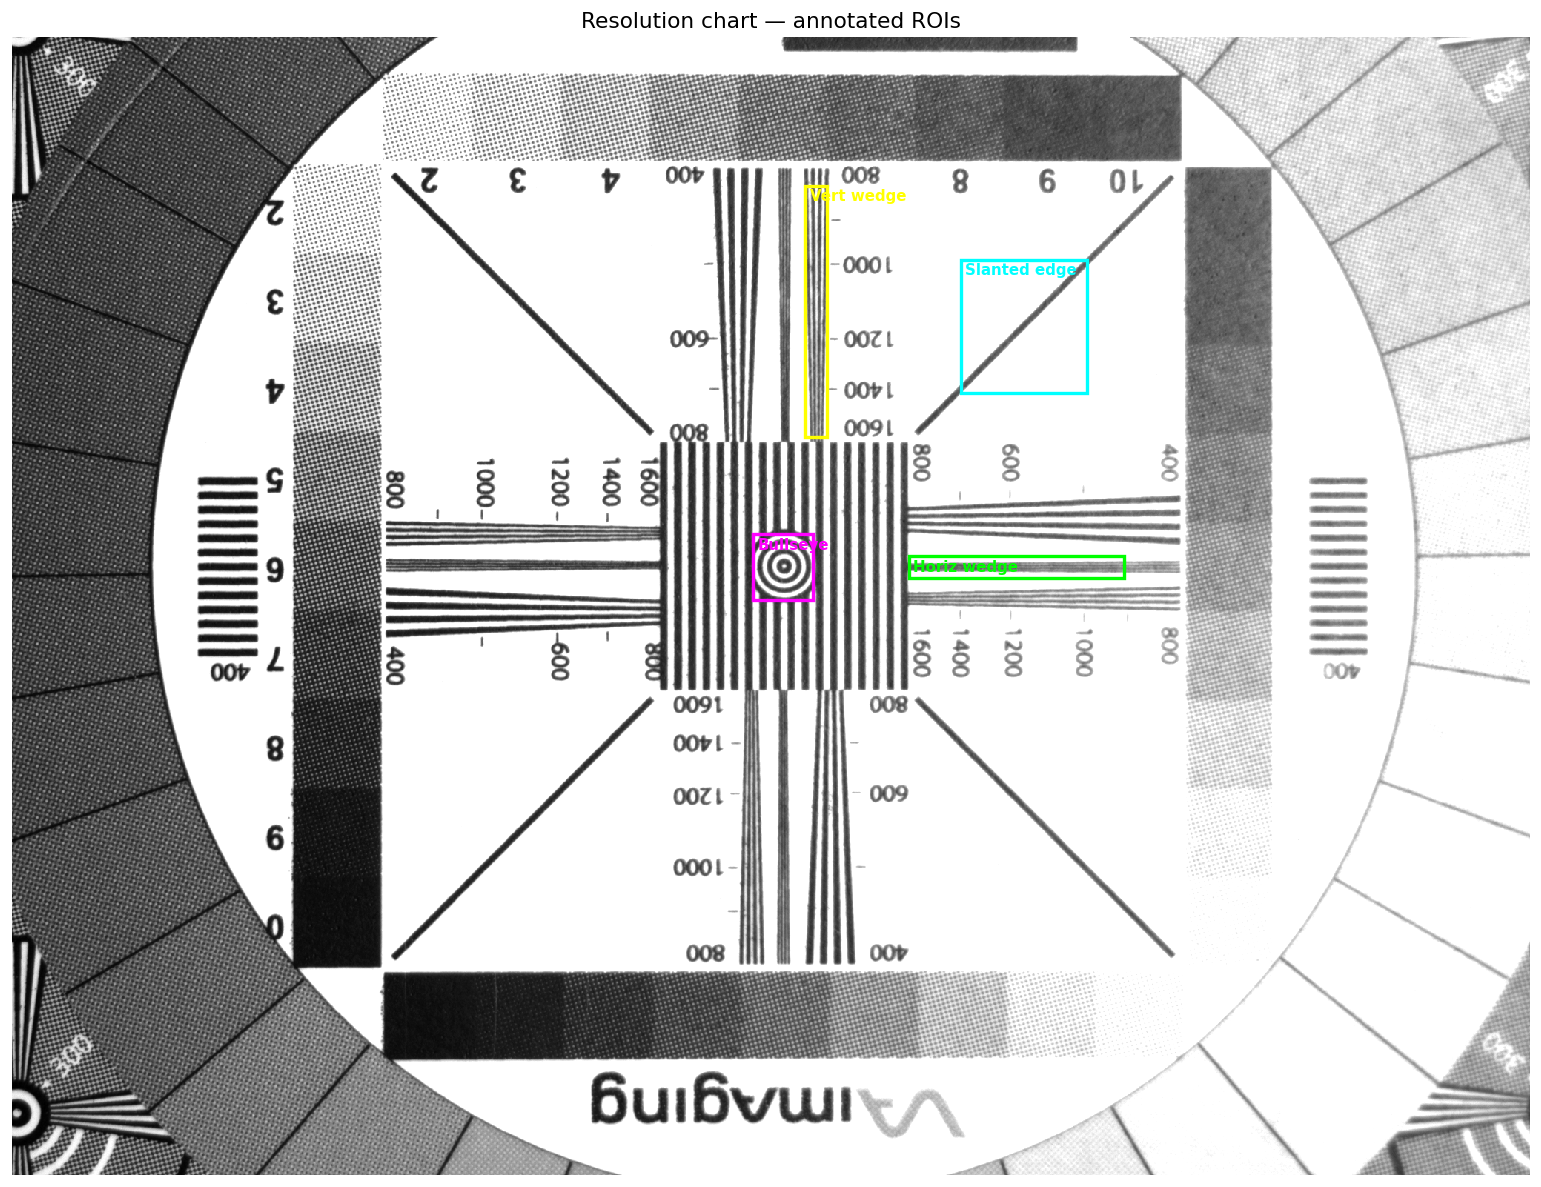

In [85]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(img, cmap='gray', interpolation='nearest')

for name, (r0, r1, c0, c1) in ROIS.items():
    rect = Rectangle((c0, r0), c1-c0, r1-r0,
                     lw=2, edgecolor=ROI_COLORS[name], facecolor='none')
    ax.add_patch(rect)
    ax.text(c0+6, r0+20, name, color=ROI_COLORS[name], fontsize=9, fontweight='bold')

ax.set_title('Resolution chart — annotated ROIs', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Zoomed ROI crops

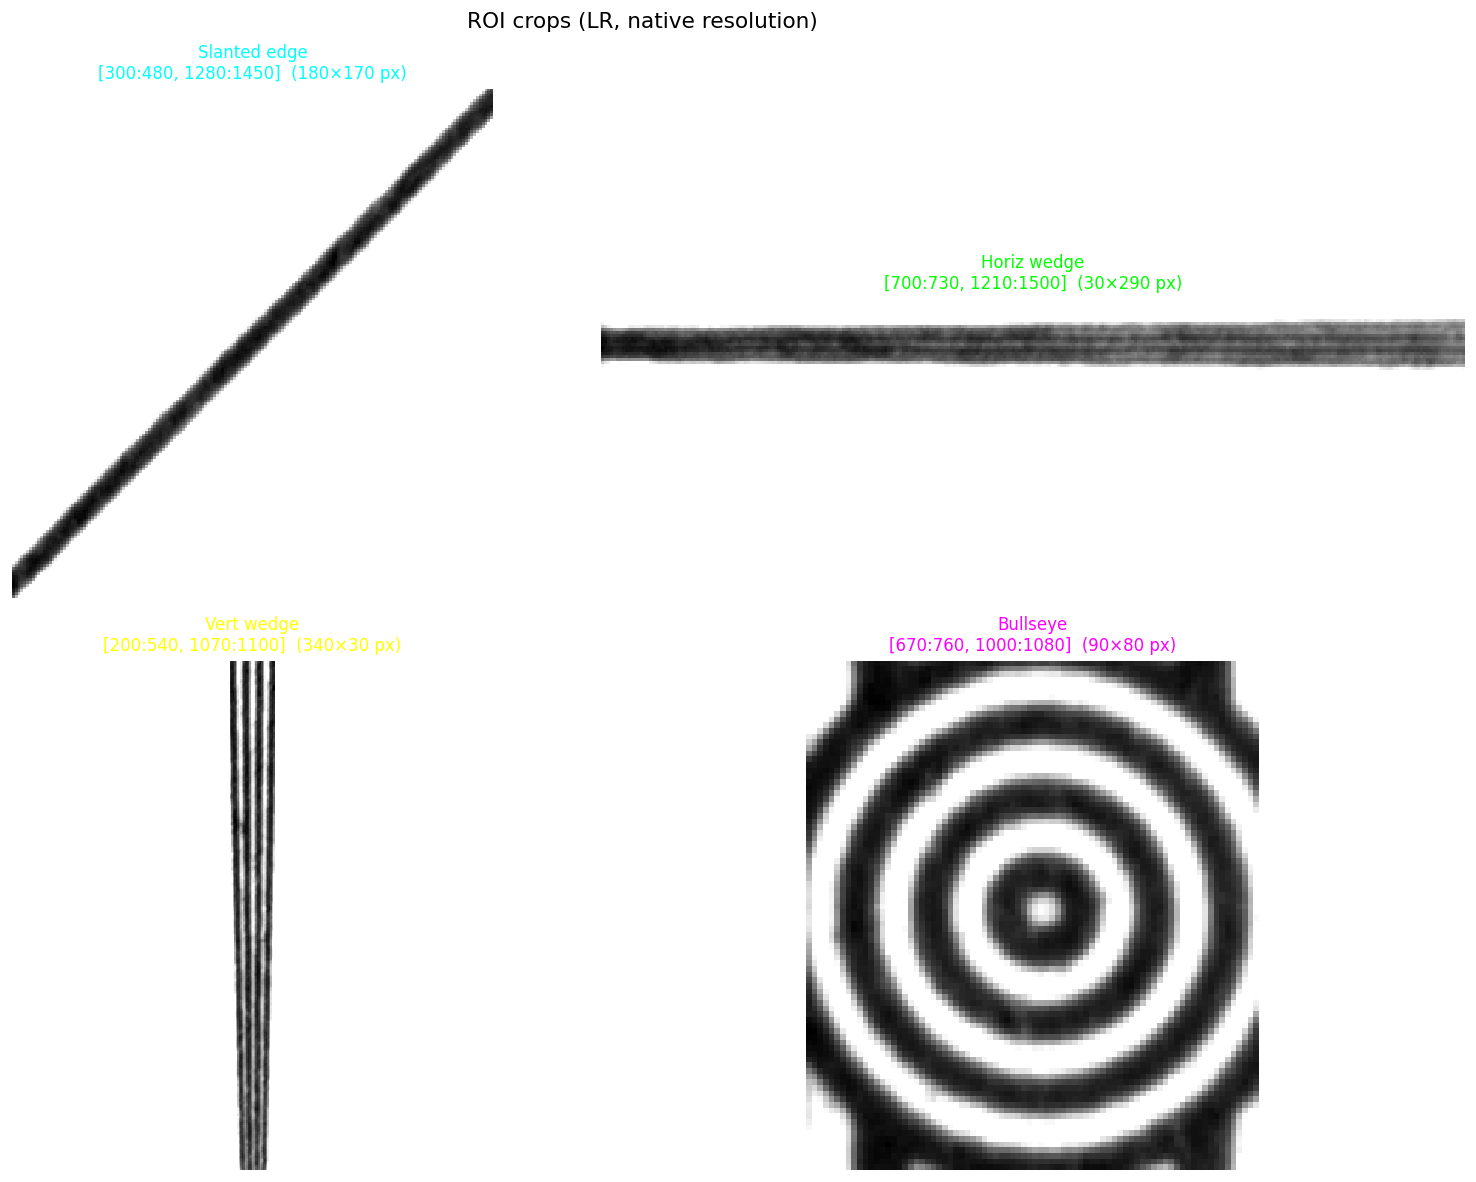

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, (r0, r1, c0, c1)) in zip(axes.flat, ROIS.items()):
    crop = img[r0:r1, c0:c1]
    ax.imshow(crop, cmap='gray', interpolation='nearest')
    ax.set_title(f'{name}\n[{r0}:{r1}, {c0}:{c1}]  ({r1-r0}×{c1-c0} px)',
                 color=ROI_COLORS[name], fontsize=10)
    ax.axis('off')

plt.suptitle('ROI crops (LR, native resolution)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Horizontal wedge — line contrast vs position
Take row-averaged vertical profiles across the wedge at each horizontal position
to measure where contrast drops off (= resolution limit).

IndexError: index 350 is out of bounds for axis 1 with size 290

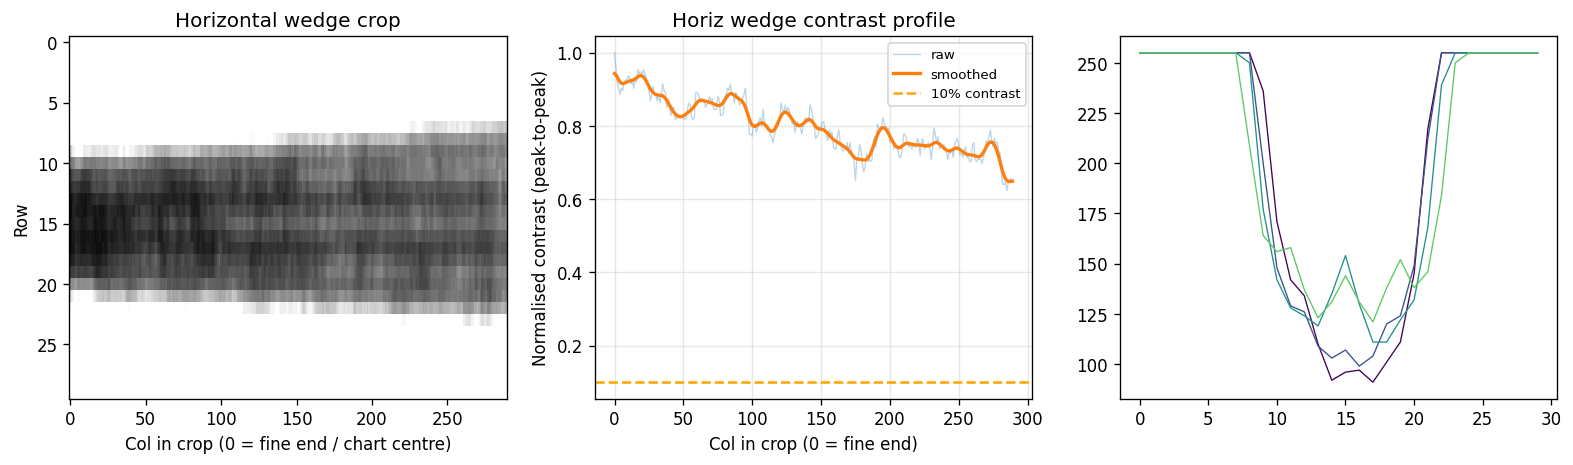

In [87]:
def wedge_contrast_profile(img_crop, axis='h', window=5, smooth=3):
    """
    For a converging-line wedge, estimate local Michelson contrast
    at each position along the axis of convergence.

    axis='h'  → lines are horizontal, wedge converges along cols (measure col by col)
    axis='v'  → lines are vertical,   wedge converges along rows (measure row by row)

    Returns positions (px from fine end) and contrast values.
    """
    if axis == 'h':
        # For each column, take the vertical profile and compute peak-to-peak contrast
        n = img_crop.shape[1]
        contrasts = np.zeros(n)
        for c in range(n):
            col = img_crop[:, c]
            contrasts[c] = col.max() - col.min()
    else:
        n = img_crop.shape[0]
        contrasts = np.zeros(n)
        for r in range(n):
            row = img_crop[r, :]
            contrasts[r] = row.max() - row.min()

    contrasts_norm = contrasts / contrasts.max()
    contrasts_smooth = gaussian_filter1d(contrasts_norm, sigma=smooth)
    return contrasts_norm, contrasts_smooth


r0, r1, c0, c1 = Hwedge_ROI
hcrop = img[r0:r1, c0:c1]

# The wedge converges toward the LEFT (low column index = fine lines)
# So col 0 in crop = finest lines, col 449 = coarsest
raw_h, smooth_h = wedge_contrast_profile(hcrop, axis='h')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.imshow(hcrop, cmap='gray', interpolation='nearest', aspect='auto')
ax.set_title('Horizontal wedge crop')
ax.set_xlabel('Col in crop (0 = fine end / chart centre)')
ax.set_ylabel('Row')

ax = axes[1]
ax.plot(raw_h, alpha=0.3, lw=0.8, label='raw')
ax.plot(smooth_h, lw=2, label='smoothed')
ax.axhline(0.1, ls='--', color='orange', label='10% contrast')
ax.set_xlabel('Col in crop (0 = fine end)')
ax.set_ylabel('Normalised contrast (peak-to-peak)')
ax.set_title('Horiz wedge contrast profile')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Show a few sample column profiles (vertical slices)
ax = axes[2]
sample_cols = [20, 60, 120, 220, 350]
colors = plt.cm.viridis(np.linspace(0, 1, len(sample_cols)))
for col, c in zip(sample_cols, colors):
    ax.plot(hcrop[:, col], color=c, lw=0.8, label=f'col {col}')
ax.set_xlabel('Row')
ax.set_ylabel('Intensity')
ax.set_title('Vertical profiles at sample columns\n(fine → coarse)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Horizontal wedge analysis', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Vertical wedge — line contrast vs position

IndexError: index 400 is out of bounds for axis 0 with size 340

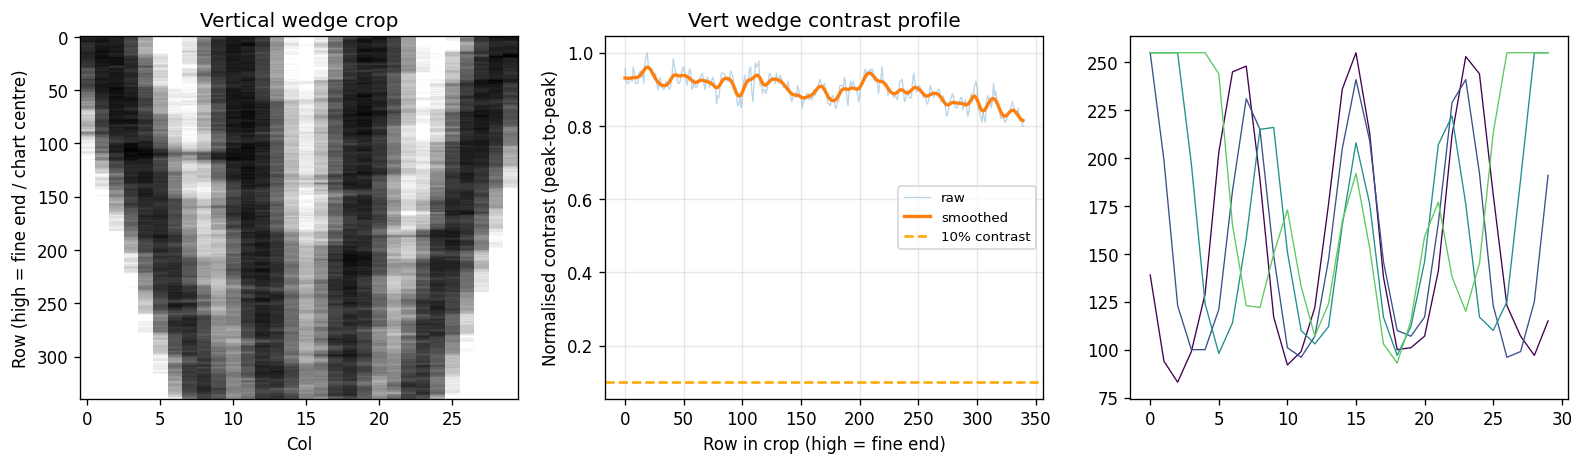

In [88]:
r0, r1, c0, c1 = VWEDGE_ROI
vcrop = img[r0:r1, c0:c1]

# The wedge converges toward the BOTTOM (high row index = fine lines near chart centre)
raw_v, smooth_v = wedge_contrast_profile(vcrop, axis='v')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.imshow(vcrop, cmap='gray', interpolation='nearest', aspect='auto')
ax.set_title('Vertical wedge crop')
ax.set_xlabel('Col')
ax.set_ylabel('Row (high = fine end / chart centre)')

ax = axes[1]
ax.plot(raw_v, alpha=0.3, lw=0.8, label='raw')
ax.plot(smooth_v, lw=2, label='smoothed')
ax.axhline(0.1, ls='--', color='orange', label='10% contrast')
ax.set_xlabel('Row in crop (high = fine end)')
ax.set_ylabel('Normalised contrast (peak-to-peak)')
ax.set_title('Vert wedge contrast profile')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
sample_rows = [50, 120, 200, 300, 400]
colors = plt.cm.viridis(np.linspace(0, 1, len(sample_rows)))
for row, c in zip(sample_rows, colors):
    ax.plot(vcrop[row, :], color=c, lw=0.8, label=f'row {row}')
ax.set_xlabel('Col')
ax.set_ylabel('Intensity')
ax.set_title('Horizontal profiles at sample rows\n(coarse → fine)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Vertical wedge analysis', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Slanted edge — MTF
The diagonal spoke gives a slanted edge we can run through the standard ISO 12233 slanted-edge MTF algorithm.

  Fitted edge slope: -0.9725  (-44.20°)
  MTF50 = 1.9980 cy/px  =  579.1 cy/mm


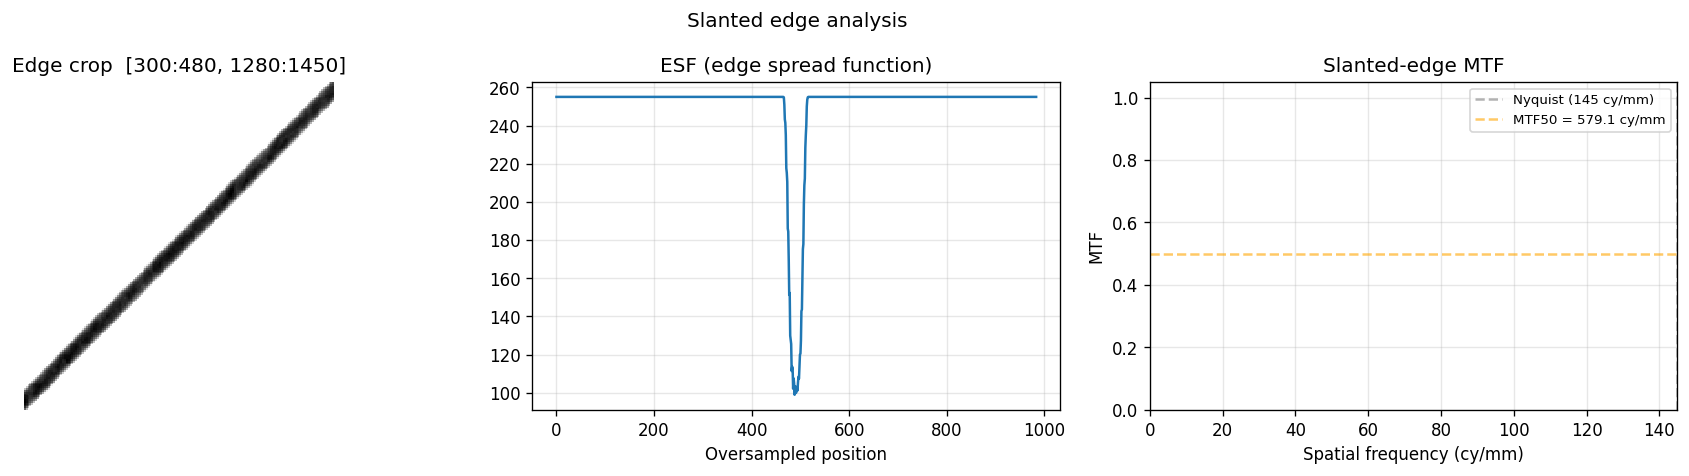

In [62]:
from scipy.ndimage import gaussian_filter

def slanted_edge_mtf(img, roi, oversample=4):
    """Slanted-edge MTF.  Returns (freq_px, mtf) where freq is in cycles/pixel."""
    r0, r1, c0, c1 = roi
    patch = img[r0:r1, c0:c1].copy()
    rows, cols = patch.shape

    # Locate edge position in each row
    edge_pts = []
    for r in range(rows):
        d = np.abs(np.diff(patch[r].astype(float)))
        if d.max() < 5:
            continue
        peaks = np.where(d > d.max() * 0.5)[0]
        if len(peaks):
            edge_pts.append((r, np.average(peaks, weights=d[peaks])))
    if len(edge_pts) < 10:
        print('Not enough edge points found — check ROI')
        return None, None

    edge_pts = np.array(edge_pts)
    slope, intercept = np.polyfit(edge_pts[:, 0], edge_pts[:, 1], 1)
    angle_deg = np.degrees(np.arctan(slope))
    print(f'  Fitted edge slope: {slope:.4f}  ({angle_deg:.2f}°)')
    cos_a = np.cos(np.arctan(slope))

    dists, vals = [], []
    for r in range(rows):
        edge_c = slope * r + intercept
        for c in range(cols):
            dists.append((c - edge_c) * cos_a)
            vals.append(patch[r, c])

    dists = np.array(dists)
    vals  = np.array(vals)
    bw    = 1.0 / oversample
    bins  = np.arange(dists.min(), dists.max(), bw)
    esf   = np.zeros(len(bins))
    cnt   = np.zeros(len(bins))
    idx   = np.clip(((dists - dists.min()) / bw).astype(int), 0, len(bins) - 1)
    np.add.at(esf, idx, vals)
    np.add.at(cnt, idx, 1)
    valid = cnt > 0
    esf[valid] /= cnt[valid]
    esf[~valid] = np.interp(bins[~valid], bins[valid], esf[valid])

    lsf   = np.diff(gaussian_filter(esf, sigma=0.5))
    lsf_w = lsf * np.hanning(len(lsf))
    mtf   = np.abs(np.fft.rfft(lsf_w))
    mtf  /= mtf[0]
    freq  = np.fft.rfftfreq(len(lsf_w), d=bw)   # cycles / pixel
    return freq, mtf, esf, lsf

r0, r1, c0, c1 = EDGE_ROI
freq, mtf, esf, lsf = slanted_edge_mtf(img, EDGE_ROI)

if freq is not None:
    # MTF50
    mtf50_px = np.interp(0.5, mtf[::-1], freq[::-1])
    mtf50_cymm = mtf50_px / PITCH_LR_MM
    print(f'  MTF50 = {mtf50_px:.4f} cy/px  =  {mtf50_cymm:.1f} cy/mm')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(img[r0:r1, c0:c1], cmap='gray', interpolation='nearest')
    axes[0].set_title(f'Edge crop  [{r0}:{r1}, {c0}:{c1}]')
    axes[0].axis('off')

    axes[1].plot(esf)
    axes[1].set_title('ESF (edge spread function)')
    axes[1].set_xlabel('Oversampled position'); axes[1].grid(True, alpha=0.3)

    ax = axes[2]
    freq_cymm = freq / PITCH_LR_MM
    ax.plot(freq_cymm, mtf, lw=1.5)
    ax.axvline(NYQUIST_LR, ls='--', color='gray', alpha=0.6, label=f'Nyquist ({NYQUIST_LR:.0f} cy/mm)')
    ax.axhline(0.5, ls='--', color='orange', alpha=0.6, label=f'MTF50 = {mtf50_cymm:.1f} cy/mm')
    ax.set_xlabel('Spatial frequency (cy/mm)')
    ax.set_ylabel('MTF')
    ax.set_xlim(0, NYQUIST_LR)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_title('Slanted-edge MTF')

    plt.suptitle('Slanted edge analysis', fontsize=12)
    plt.tight_layout()
    plt.show()

## 8. Quick SR preview — SAA on each ROI
Apply shift-and-add to the 4 shifted frames to see if SR improves the wedge visibility.

In [63]:
from scipy.ndimage import shift as ndi_shift, zoom as ndi_zoom

NOMINAL_SHIFTS = [(-0.5, -0.5), (+0.5, -0.5), (-0.5, +0.5), (+0.5, +0.5)]
f = 2   # upsample factor

shifts = [np.array(Image.open(f'{SAMPLE_DIR}/shift_{i}.png'), dtype=np.float64)
          for i in range(4)]

def shift_and_add(lr_list, shifts_yx, factor=2):
    h, w = lr_list[0].shape
    acc = np.zeros((h * factor, w * factor))
    for lr, (dy, dx) in zip(lr_list, shifts_yx):
        up = ndi_zoom(lr, factor, order=3)
        acc += ndi_shift(up, (dy * factor, dx * factor), order=3, mode='nearest')
    return acc / len(lr_list)

native_2x = ndi_zoom(img, f, order=3)
saa       = shift_and_add(shifts, NOMINAL_SHIFTS, f)

print('Native 2× shape:', native_2x.shape)
print('SAA shape:       ', saa.shape)

Native 2× shape: (3072, 4096)
SAA shape:        (3072, 4096)


In [ ]:
# Compare native 2× vs SAA on each ROI crop
rois_to_compare = [
    ('Horiz wedge',  Hwedge_ROI),
    ('Vert wedge',   VWEDGE_ROI),
    ('Slanted edge', EDGE_ROI),
]

fig, axes = plt.subplots(len(rois_to_compare), 2, figsize=(14, 5 * len(rois_to_compare)))

for row, (name, (r0, r1, c0, c1)) in enumerate(rois_to_compare):
    r0h, r1h, c0h, c1h = r0*f, r1*f, c0*f, c1*f

    axes[row, 0].imshow(native_2x[r0h:r1h, c0h:c1h], cmap='gray', interpolation='nearest')
    axes[row, 0].set_title(f'{name} — Bicubic 2×', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(saa[r0h:r1h, c0h:c1h], cmap='gray', interpolation='nearest')
    axes[row, 1].set_title(f'{name} — SAA (nominal ±0.5 px)', fontsize=10)
    axes[row, 1].axis('off')

plt.suptitle('Bicubic 2× vs SAA — crop comparison', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Summary — confirmed ROIs

Copy these into `sweep_sr.py` when adapting the pipeline for this dataset.

```python
# ── ROI definitions for 20260323_202456 dataset ──
EDGE_ROI    = (120, 420, 1480, 1850)   # slanted diagonal spoke, top-right
Hwedge_ROI  = (640, 880, 1080, 1530)  # horizontal converging lines (fine end LEFT)
VWEDGE_ROI  = (80,  520, 860,  1170)  # vertical converging lines   (fine end BOTTOM)

# Combined bounding box for SR crop (covers all three ROIs):
CROP_R0, CROP_R1 = 80,  880
CROP_C0, CROP_C1 = 860, 1850
# → 800 × 990 LR pixels  →  1600 × 1980 HR pixels
```

**Metric plan:**
- **Slanted edge MTF50** (cy/mm) from `EDGE_ROI` — same algorithm as before
- **Wedge resolution limit** from `Hwedge_ROI` / `VWEDGE_ROI` — column/row position
  where contrast drops below 10%, converted to spatial frequency via the chart's
  TVL/PH scale (needs one-time calibration of the px↔TVL/PH mapping below)


In [ ]:
# ── One-time calibration: map crop column → spatial frequency (cy/mm) ──
#
# The chart labels lines in TVL/PH (TV lines per picture height).
# Picture height = 1536 px × 3.45 µm = 5.2992 mm
# 1 TVL/PH = 0.5 cy / (picture height in mm)
# → 1 TVL/PH = 0.5 / 5.2992 cy/mm = 0.09435 cy/mm

PH_MM = 1536 * PIXEL_PITCH_UM * 1e-3    # picture height in mm
TVL_TO_CYMM = 0.5 / PH_MM               # cy/mm per TVL/PH
print(f'Picture height: {PH_MM:.4f} mm')
print(f'1 TVL/PH = {TVL_TO_CYMM:.4f} cy/mm')
print()

# ── Manually identify which col in HCROP corresponds to which TVL/PH label ──
# From the image, visible labels and their approximate column positions in the crop:
#   1600 TVL/PH → col ~60   (fine end, left side of crop)
#   1400 TVL/PH → col ~130
#   1200 TVL/PH → col ~210
#   1000 TVL/PH → col ~320
#    800 TVL/PH → col ~400  (coarse end, right side)
#
# Fit a linear mapping: TVL/PH = a * col + b

calib_cols = np.array([60,  130, 210, 320, 400])
calib_tvl  = np.array([1600, 1400, 1200, 1000, 800])

a, b = np.polyfit(calib_cols, calib_tvl, 1)
print(f'Calibration fit: TVL/PH = {a:.2f} × col + {b:.1f}')
print(f'  At col=0  (fine end): {b:.0f} TVL/PH = {b*TVL_TO_CYMM:.1f} cy/mm')
print(f'  At col=449 (coarse):  {a*449+b:.0f} TVL/PH = {(a*449+b)*TVL_TO_CYMM:.1f} cy/mm')

# Helper to convert crop col → cy/mm
def hcrop_col_to_cymm(col):
    tvl = a * col + b
    return tvl * TVL_TO_CYMM

# Show calibration
fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(calib_cols, calib_tvl * TVL_TO_CYMM, s=60, zorder=3, label='Labelled points')
cols_fit = np.arange(0, 450)
ax.plot(cols_fit, (a * cols_fit + b) * TVL_TO_CYMM, lw=1.5, label='Linear fit')
ax.set_xlabel('Col in horiz wedge crop')
ax.set_ylabel('Spatial frequency (cy/mm)')
ax.set_title('Horiz wedge: col ↔ spatial frequency calibration')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()